Importar Librerias

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

Cargar Dataset

In [2]:
url = "https://raw.githubusercontent.com/CDOM24/Taller-ANN/main/riesgo.csv"

df = pd.read_csv(url, sep=";")

df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,"17,375",913-74-1218,Lawyer,"30625,94","2706,161667",6,5,27,...,Bad,"1562,91","33,47754647","10,45833333",Yes,"42,94109042","158,5497352",High_spent_Medium_value_payments,"335,3753411",0
1,CUS_0x1009,Arunah,"25,75",063-67-6938,Mechanic,"52312,68","4250,39",6,5,17,...,Standard,"202,68","29,83998399","30,71428571",Yes,"108,3664671","146,6793779",High_spent_Medium_value_payments,"428,743155",1
2,CUS_0x100b,Shirboni,"18,5",238-62-0395,Media_Manager,"113781,39","9549,7825",1,4,1,...,Good,"1030,2","34,84144912","15,57142857",No,0,"505,3865264",High_spent_Large_value_payments,"781,2297763",0
3,CUS_0x1011,Schneyerh,"43,875",793-05-8223,Doctor,"58918,47","5208,8725",3,3,17,...,Standard,"473,14","27,65589672","15,54166667",Yes,"123,4349388","311,0609143",Low_spent_Medium_value_payments,"332,6428375",1
4,CUS_0x1013,Cameront,"43,75",930-49-9615,Mechanic,"98620,98","7962,415",3,3,6,...,Good,"1233,51","31,93394005","17,53571429",No,"228,0180837","355,4424076",High_spent_Medium_value_payments,"472,7810087",1


Información del dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Customer_ID               12500 non-null  object
 1   Name                      12500 non-null  object
 2   Age                       12500 non-null  object
 3   SSN                       12500 non-null  object
 4   Occupation                12500 non-null  object
 5   Annual_Income             12500 non-null  object
 6   Monthly_Inhand_Salary     12500 non-null  object
 7   Num_Bank_Accounts         12500 non-null  object
 8   Num_Credit_Card           12500 non-null  object
 9   Interest_Rate             12500 non-null  int64 
 10  Num_of_Loan               12500 non-null  int64 
 11  Type_of_Loan              11074 non-null  object
 12  Delay_from_due_date       12500 non-null  object
 13  Num_of_Delayed_Payment    12500 non-null  object
 14  Changed_Credit_Limit  

Distribución del Credit Score

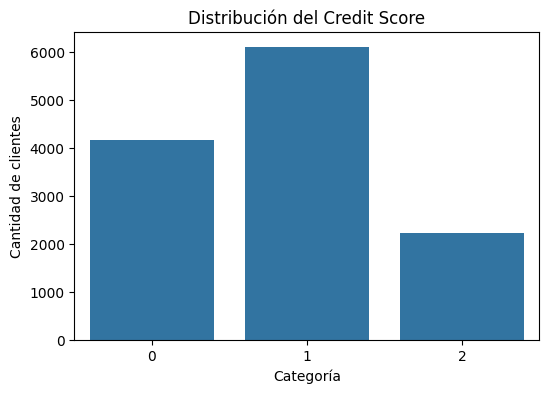

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="Credit_Score", data=df)

plt.title("Distribución del Credit Score")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de clientes")

plt.show()

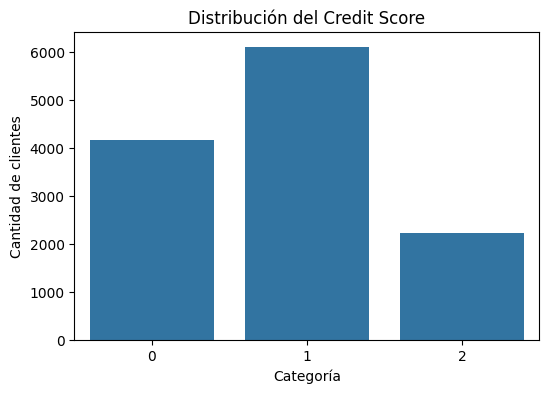

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x="Credit_Score", data=df)

plt.title("Distribución del Credit Score")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de clientes")

plt.show()

In [6]:

df = df.drop(columns=["Customer_ID","Name","SSN"])

In [12]:
X = df[[
    "Age",
    "Annual_Income",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Outstanding_Debt",
    "Monthly_Balance"
]]

y = df["Credit_Score"]

# reemplazar coma por punto
X = X.replace(",", ".", regex=True)

# convertir a número
X = X.astype(float)

In [15]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
y_train = to_categorical(y_train, 3)
y_test = to_categorical(y_test, 3)

In [19]:
model = Sequential([
    
    Dense(16, activation="relu", input_shape=(6,)),
    
    Dense(8, activation="relu"),
    
    Dense(3, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5624 - loss: 0.9714 - val_accuracy: 0.6110 - val_loss: 0.8805
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6013 - loss: 0.8615 - val_accuracy: 0.6220 - val_loss: 0.8422
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6324 - loss: 0.8208 - val_accuracy: 0.6350 - val_loss: 0.8283
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6474 - loss: 0.7989 - val_accuracy: 0.6470 - val_loss: 0.8129
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6533 - loss: 0.7916 - val_accuracy: 0.6465 - val_loss: 0.8083
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6587 - loss: 0.7842 - val_accuracy: 0.6500 - val_loss: 0.8012
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6668 - loss: 0.7633 - val_accuracy: 0.6495 - val_loss: 0.7934
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6694 - loss: 0.7734 - val_accuracy: 0.

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Precisión del modelo:", accuracy)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6934 - loss: 0.7256
Precisión del modelo: 0.6848000288009644


In [23]:


model.save("modelo_credit_score.keras")

In [24]:
ejemplo = np.array([[35, 50000, 3, 2, 1200, 2000]])

ejemplo = scaler.transform(ejemplo)

pred = model.predict(ejemplo)

print("Predicción:", pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
Predicción: [[0.08304788 0.10205805 0.81489414]]


In [25]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']